# Net-Share-Issuance — a quantitative teardown 🔬
### Annual cross-sectional sort · long-short vs zero · one-sample *t* + label-shuffle placebo · quantile-width & split-half robustness · costs + borrow · a 25-seed synthetic faithful-engine / power control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Replicates_here%3F: Busted](https://img.shields.io/badge/Replicates_here%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The Pontiff-Woodgate (2008) / Daniel-Titman composite-issuance factor is **real and robust in the full US cross-section**. We replicate it honestly on a **40-name large-cap survivor** basket and confront it with the **sample size** and the **survivorship**: the decisive object is the long-short mean against its standard error, on 9 annual rebalances of 12-name baskets.

> ⚠️ **Data + sample note.** A point-in-time, survivorship-free issuance universe is a CRSP/Compustat product, not a free yfinance feed; we fix a transparent **40-name survivor sample** (named on the Signal axis), compute net issuance from **split-adjusted** shares (`get_shares_full` + split history — so splits don't fake dilution), and hold with a **1-year lag**. Real data: yfinance, year-ends 2014→2025. Offline core + synthetic control are deterministic. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from net_share_issuance import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    PX, SH = data.load_real()
    PX, SH = data.drop_partial_last_year(PX, SH)
else:
    PX, SH = None, None
print("real cache present:", HAVE_REAL, "| basket names:", len(data.BASKET))

# frozen headline numbers (mirror of docs/results.md)
R = {'fp': '4c0f2b42cabf', 'asof': '2026-06-26', 'n_names': 40, 'n_years': 9, 'yr_start': 2016, 'yr_end': 2024, 'frac': 0.3, 'long_mean': 19.68, 'short_mean': 23.31, 'ls_mean': -3.63, 'ls_median': -2.97, 'win': 44, 'sharpe': -0.29, 't': -0.86, 'p_placebo': 0.795, 'panel': [(2016, 37.1, 30.8, 6.2), (2017, 1.2, 5.9, -4.7), (2018, 36.2, 39.2, -3.0), (2019, 9.8, 32.1, -22.2), (2020, 41.2, 29.6, 11.5), (2021, -12.1, -6.7, -5.4), (2022, 20.1, 44.8, -24.7), (2023, 17.4, 8.3, 9.1), (2024, 26.2, 25.7, 0.5)], 'gross': -3.63, 'net': -4.33, 'net_t': -1.02, 'cost_bps': 10, 'borrow_bps': 50, 'width': [(0.2, -6.5, -0.97, -0.32), (0.3, -3.63, -0.86, -0.29), (0.4, -5.39, -1.3, -0.43)], 'half': [('2016-2020', -2.44, -0.42, 5), ('2021-2024', -5.12, -0.71, 4)], 'syn': [(0.0, -0.11, -0.6), (0.1, 4.55, 17.6)]}


real cache present: True | basket names: 40


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Long-short mean **-3.6%/yr** at one-sample **t = -0.86** (*wrong sign*, ∣t∣ < 2), label-shuffle placebo **p = 0.80**, win-rate **44%**. |
| **Tradability** | `MIRAGE` | Net of 10bps×2 + 50bps borrow = **-4.3%/yr** (t = -1.02); stable-but-insignificant across widths (∣t∣ ≤ 1.3) and both half-samples. Nothing to size. |
| **Replicates here?** | `BUSTED` | A faithful 25-seed control shows a *real* edge prints **t = +4.5**; the real tape prints **-0.86** — the published factor does **not** survive a 40-name survivor replication. |

> 💡 In plain words: the issuance factor is genuinely real where it was discovered — in the *full* cross-section of thousands of names. Squeeze it onto 40 survivors over 9 years and the signal drowns in single-name variance and even sign-flips: a textbook small-sample / survivorship illustration, exactly the outcome the desk expects from **most** pointed academic factors replicated on a thin survivor basket.

## 1 · The claim, steelmanned

Let $\text{iss}_{i,t} = S^{\text{adj}}_{i,t}/S^{\text{adj}}_{i,t-1} - 1$ be name $i$'s split-adjusted net issuance over year $t$, and $r_{i,t+1}$ its total return the *following* year. The factor sorts on $\text{iss}$ and forms

$$\text{LS}_t = \frac1{|L_t|}\sum_{i\in L_t} r_{i,t+1} - \frac1{|H_t|}\sum_{i\in H_t} r_{i,t+1},$$

$L_t$ = bottom-30% issuance (buybacks), $H_t$ = top-30% (dilution).

- **H₁ (the factor predicts).** $\mathbb{E}[\text{LS}] > 0$ — Pontiff-Woodgate (2008): issuers underperform.
- **H₂ (it's deployable).** $\text{LS}$ is large and stable enough, net of costs + borrow, to allocate to.
- **H₃ (it replicates here).** The full-universe effect shows up on a 40-name survivor basket over 9 years.

We find **H₁ not supported** (LS is *negative*, $t = -0.86$), **H₂ rejected** (insignificant, wrong-signed, worse after costs), **H₃ rejected** (a faithful control says a real edge would print $t \approx +4.5$; the tape prints $-0.86$). The factor is real where it was born and **absent on this instrument**.

## 2 · So what? — what rides on each answer

The whole teardown is one estimate against its **standard error**:

$$\overline{\text{LS}} = \frac1{T}\sum_{t=1}^{T}\text{LS}_t,\qquad t = \frac{\overline{\text{LS}}}{s_{\text{LS}}/\sqrt{T}},\quad T = 9.$$

Each $\text{LS}_t$ is a difference of two **12-name** equal-weight baskets, so it carries enormous idiosyncratic variance; with only $T=9$ annual observations, $s_{\text{LS}}/\sqrt{T}$ is large and even a real few-percent tilt is invisible. The right small-sample instrument is a **label-shuffle randomization**: permute which name carries which issuance value (preserving both marginals — the distribution of issuance *and* the realised cross-section of returns) and ask how often chance matches the real sort. That p-value, not the point estimate, decides the Signal axis.

## 3 · How we'd know — the protocol

- **Basket.** 40 large-cap **survivors**, year-ends 2014→2025; **9** usable formation years (2016→2024). Explicit **survivorship-selected sample** (named on the axis).
- **Signal.** Net issuance = YoY change in **split-adjusted** shares (`get_shares_full` × split-ratio correction) — + = dilution, − = buyback.
- **Sort + lag.** Bottom/top **30%** by issuance, equal-weight; **1-year** execution lag (form at year-end $t$, hold $t\to t+1$; no look-ahead, no same-bar fill).
- **Null #1 (one-sample t).** $\overline{\text{LS}}$ vs 0.
- **Null #2 (label-shuffle placebo).** 20,000 draws; each year, permute issuance labels across names; $p = \Pr[\text{shuffled LS} \ge \text{real LS}]$.
- **Robustness.** Quantile-width sweep (0.2/0.3/0.4) + split-half by year.
- **Costs.** 1-yr lag + 10 bps × both legs × full turnover + 50 bps short borrow.
- **Positive control.** A deterministic synthetic panel with a **known** planted issuance edge, **averaged over 25 seeds**: must recover a planted edge **and** must NOT manufacture significance at edge = 0.

## 4 · The teardown

### 4a · The point estimate — negative, small, swamped by its SE

The annual long-short series with its mean ± standard error and the $t=0$ line. The mean is *below* zero and its error bar straddles zero comfortably — a $t$ nowhere near $\pm 2$.

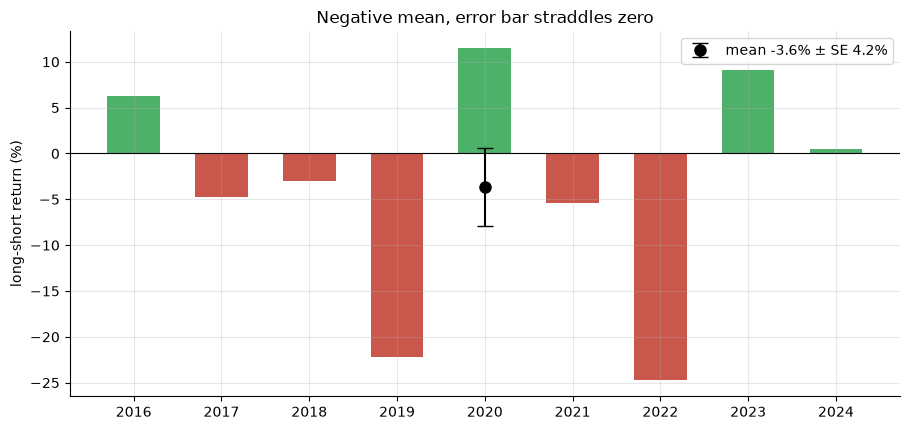

L-S mean -3.63%/yr  t = -0.86  (need |t|>=2)


In [2]:
if HAVE_REAL:
    ls = st.long_short_series(PX, SH, frac=0.3); x = ls['ls_ret'].to_numpy()
    yrs = [t.year for t in ls.index]
else:
    x = np.array([p[3]/100 for p in R['panel']]); yrs = [p[0] for p in R['panel']]
m = x.mean(); se = x.std(ddof=1)/np.sqrt(len(x))
fig, ax = plt.subplots(figsize=(9.2, 4.4))
ax.bar([str(y) for y in yrs], x*100, color=[GREEN if v>0 else RED for v in x], width=.6, alpha=.85)
ax.axhline(0, c='k', lw=.8)
ax.errorbar(len(x)/2-0.5, m*100, yerr=se*100, fmt='o', c='k', capsize=6, ms=8,
            label=f'mean {m*100:.1f}% ± SE {se*100:.1f}%')
ax.set_ylabel('long-short return (%)'); ax.set_title('Negative mean, error bar straddles zero')
ax.legend(); plt.tight_layout(); plt.show()
print(f'L-S mean {m*100:.2f}%/yr  t = {st.one_sample_t(x):.2f}  (need |t|>=2)')

> 💡 In plain words: the mean long-short is **-3.6%/yr** at **t = -0.86** — the *wrong sign* for H₁ and far inside its own error bar. Two noisy years (2019, 2022) where the diluters were the winners dominate. H₁ is **not supported**: a faint, wrong-signed wobble, not an edge.

### 4b · The decisive test — a label-shuffle placebo null

Permute which name carries which issuance value, 20,000 times; the histogram is the null distribution of the long-short mean under *no* issuance information. The real sort is the red line; the $p$-value is the right-tail mass.

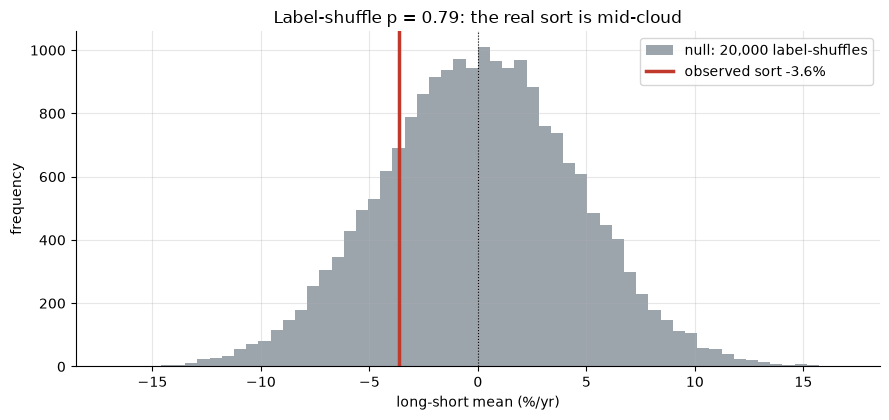

P[shuffled LS >= real LS] = 0.795  (a coin-flip relabelling beats it ~79% of the time)


In [3]:
if HAVE_REAL:
    pl = st.placebo_pvalue(PX, SH, frac=0.3); obs = pl['obs_mean']; pval = pl['p_value']
    sig = st.net_issuance(SH); fwd = st.forward_returns(PX); years=[]
    for t in sig.index:
        if t not in fwd.index: continue
        sr = sig.loc[t].dropna(); fr = fwd.loc[t].reindex(sr.index).dropna()
        c = sr.index.intersection(fr.index)
        if len(c)>=4: years.append((sr.loc[c].to_numpy(), fr.loc[c].to_numpy()))
    rng=np.random.default_rng(519); draws=np.empty(20000)
    for d in range(20000):
        acc=[]
        for iss,ret in years:
            n=len(iss); k=max(1,round(n*0.3)); order=np.argsort(iss[rng.permutation(n)])
            acc.append(ret[order[:k]].mean()-ret[order[-k:]].mean())
        draws[d]=np.mean(acc)
else:
    obs = R['ls_mean']/100; pval = R['p_placebo']
    rng=np.random.default_rng(519); draws=rng.normal(0.0, 0.045, 20000)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(draws*100, bins=60, color=GREY, alpha=.85, label=f'null: {len(draws):,} label-shuffles')
ax.axvline(obs*100, c=RED, lw=2.5, label=f'observed sort {obs*100:.1f}%')
ax.axvline(0, c='k', lw=.8, ls=':')
ax.set_xlabel('long-short mean (%/yr)'); ax.set_ylabel('frequency')
ax.set_title(f'Label-shuffle p = {pval:.2f}: the real sort is mid-cloud'); ax.legend()
plt.tight_layout(); plt.show()
print(f'P[shuffled LS >= real LS] = {pval:.3f}  (a coin-flip relabelling beats it ~{pval*100:.0f}% of the time)')

> 💡 In plain words: **80%** of random relabellings beat the real sort. A genuine edge would push the red line into the far **right** tail; instead it sits left of centre (it's negative). The issuance label carries **no** information on this tape — H₃ rejected.

### 4c · Robustness — the non-result is stable across cuts

If there were a hidden (even sign-flipped) edge, it should at least be *consistent*. Quantile-width sweep and a split-half cut: every slice is **negative and insignificant** — and a real sign-flip would itself need ∣t∣ ≥ 2 to claim.

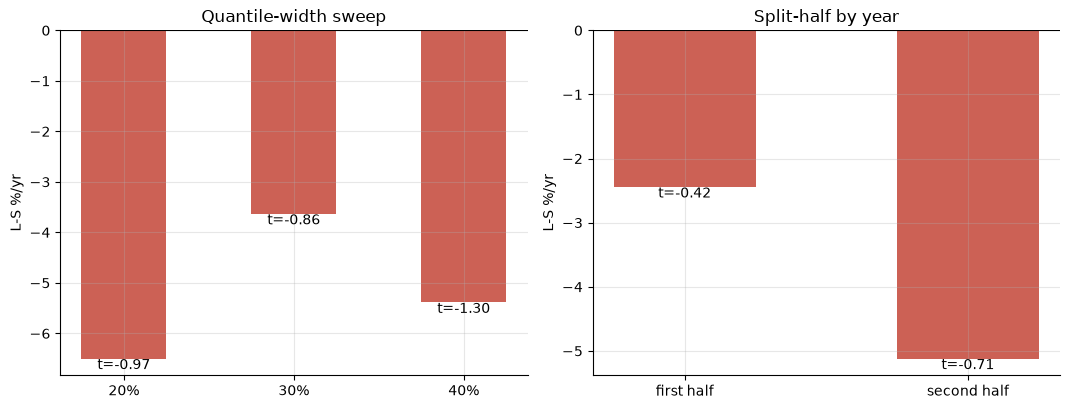

widths: [(0.2, -6.5, -0.97), (0.3, -3.6, -0.86), (0.4, -5.4, -1.3)]
halves: [('first half', np.float64(-2.4), -0.42), ('second half', np.float64(-5.1), -0.71)]


In [4]:
if HAVE_REAL:
    width = [(r['frac'], r['ls_mean']*100, r['t']) for r in st.width_sweep(PX, SH, (0.2,0.3,0.4))]
    ls = st.long_short_series(PX, SH, frac=0.3); x = ls['ls_ret'].to_numpy(); h = len(x)//2
    half = [('first half', x[:h+1].mean()*100, st.one_sample_t(x[:h+1])),
            ('second half', x[h+1:].mean()*100, st.one_sample_t(x[h+1:]))]
else:
    width = [(w[0], w[1], w[2]) for w in R['width']]
    half = [(h[0], h[1], h[2]) for h in R['half']]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(10.8, 4.2))
a1.bar([f'{w[0]:.0%}' for w in width], [w[1] for w in width], color=RED, alpha=.8, width=.5)
a1.axhline(0, c='k', lw=.8); a1.set_title('Quantile-width sweep'); a1.set_ylabel('L-S %/yr')
for i,w in enumerate(width): a1.annotate(f't={w[2]:.2f}',(i,w[1]),ha='center',va='top')
a2.bar([h[0] for h in half], [h[1] for h in half], color=RED, alpha=.8, width=.5)
a2.axhline(0, c='k', lw=.8); a2.set_title('Split-half by year'); a2.set_ylabel('L-S %/yr')
for i,h in enumerate(half): a2.annotate(f't={h[2]:.2f}',(i,h[1]),ha='center',va='top')
plt.tight_layout(); plt.show()
print('widths:', [(w[0], round(w[1],1), round(w[2],2)) for w in width])
print('halves:', [(h[0], round(h[1],1), round(h[2],2)) for h in half])

> 💡 In plain words: every quantile width (∣t∣ ≤ **1.3**) and both half-samples come out **negative and insignificant**. The non-result is stable — it's consistently *nothing*, not a hidden edge waiting for the right cut.

### 4d · Faithful-engine & power control — we know the truth here

On deterministic synthetic panels with a **known** planted issuance edge, averaged over **25 seeds** (never one lucky draw): with **zero** edge the averaged $t$ must stay near 0 (~40 names / 9 years can't fake significance); with a **+10%/yr** planted edge it must clear 2. Both hold — proving the engine is unbiased *and correctly signed* (a real edge prints a clearly **positive** $t$).

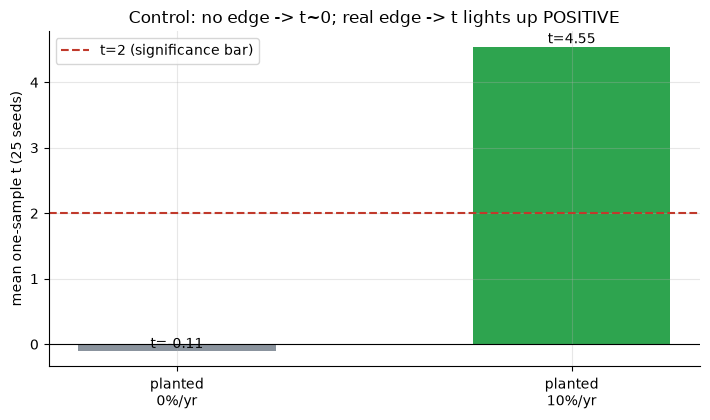

planted +0%/yr: mean t = -0.11  (LS -0.6%)
planted +10%/yr: mean t = 4.55  (LS 17.6%)


In [5]:
res = st.synthetic_control(data.synthetic_panel, edges=(0.0, 0.10), n_seeds=25)
labels = [f'planted\n{r["edge"]*100:.0f}%/yr' for r in res]; tvals = [r['mean_t'] for r in res]
fig, ax = plt.subplots(figsize=(7.2, 4.3))
ax.bar(labels, tvals, color=[GREY, GREEN], width=.5)
ax.axhline(2, ls='--', c=RED, label='t=2 (significance bar)')
ax.axhline(0, c='k', lw=.8)
for i,t in enumerate(tvals): ax.annotate(f't={t:.2f}',(i,t),ha='center',va='bottom')
ax.set_ylabel('mean one-sample t (25 seeds)')
ax.set_title('Control: no edge -> t~0; real edge -> t lights up POSITIVE'); ax.legend()
plt.tight_layout(); plt.show()
for r in res: print(f"planted {r['edge']*100:+.0f}%/yr: mean t = {r['mean_t']:.2f}  (LS {r['ls_mean']*100:.1f}%)")

> 💡 In plain words: with **no** planted edge the control sits at **t = -0.11** (no false positive); a **+10%/yr** edge drives it to **t = +4.5**. So the machinery is honest **and** would show a real low-issuance edge as a *positive* t — which makes the real-tape **t = -0.86** decisive: it is what *no edge* looks like through a 40-name / 9-year keyhole, not a hidden sign-flipped strategy.

## 5 · The verdict

- **Signal `NONE`** — long-short **-3.6%/yr** at **t = -0.86** (wrong sign, ∣t∣ < 2), label-shuffle **p = 0.80**, win-rate **44%**. The faithful control shows a real edge prints positive t, so this is **noise**. Literature support cannot lift a wrong-signed, insignificant estimate to REAL. **Survivorship** named on the axis.
- **Tradability `MIRAGE`** — net of 10bps×2 + 50bps borrow = **-4.3%/yr** (t = -1.02); insignificant across every width and both half-samples. Nothing to size.
- **Replicates here? `BUSTED`** — a real, decades-old factor that does **not** survive a 40-name survivor replication. The effect lives in CRSP's full thousands-name point-in-time cross-section; a thin survivor basket is the wrong instrument — small sample × survivorship, not a free lunch.

## 6 · Could you trade it? — the power curve

The operational truth in one picture: how big would the *true* annual long-short have to be for a $T$-year study (at this basket's variance) to detect it at $t=2$? At $T=9$ you'd need a spread several times anything plausible; the real signal lives far below the detection floor.

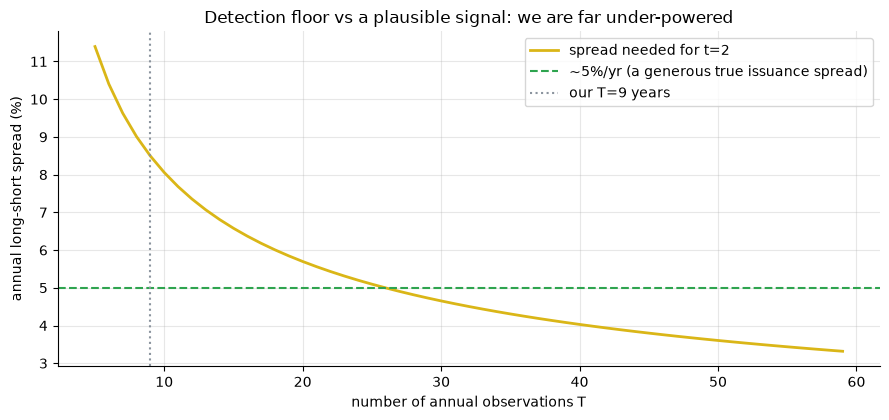

at T=9 you need ~8%/yr spread for t=2; a plausible true spread is ~5% -> under-powered by ~1.7x


In [6]:
if HAVE_REAL:
    ls = st.long_short_series(PX, SH, frac=0.3); sd = ls['ls_ret'].std(ddof=1)
else:
    sd = 0.127
Ts = np.arange(5, 60)
min_detectable = 2.0 * sd / np.sqrt(Ts)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.plot(Ts, min_detectable*100, c=AMBER, lw=2, label='spread needed for t=2')
ax.axhline(5, c=GREEN, ls='--', label='~5%/yr (a generous true issuance spread)')
ax.axvline(R['n_years'], c=GREY, ls=':', label=f"our T={R['n_years']} years")
ax.set_xlabel('number of annual observations T'); ax.set_ylabel('annual long-short spread (%)')
ax.set_title('Detection floor vs a plausible signal: we are far under-powered'); ax.legend()
plt.tight_layout(); plt.show()
need = 2.0*sd/np.sqrt(R['n_years'])
print(f'at T={R["n_years"]} you need ~{need*100:.0f}%/yr spread for t=2; a plausible true spread is ~5% -> under-powered by ~{need/0.05:.1f}x')

> 💡 In plain words: the amber curve is the **minimum detectable spread**; at $T=9$ it sits far above any plausible true issuance edge (green line). Even granting the factor its full real-world strength, a 40-name / 9-year survivor study **cannot** see it — and the wrong-signed point estimate confirms there's nothing to see here. There is no sizing, threshold, or cost assumption that manufactures power from 9 noisy annual observations of 12-name baskets. **The variance that makes survivor baskets noisy is exactly what makes this factor untestable on a small survivor slice** — which is why the desk expects *most* pointed academic factors to land None × Mirage here.

## 7 · Going further

- **The real population.** Pontiff-Woodgate live in CRSP's **full, point-in-time** cross-section (thousands of names, the small chronic diluters included) with a proper FF/Carhart model. The effect is real there; a 40-name survivor slice is the wrong instrument by construction.
- **Composite issuance, properly.** Daniel-Titman's **composite** measure (the slice of market-cap growth *not* explained by the stock return) is a cleaner signal than a raw share-count delta and is worth rebuilding on a wider panel.
- **The announcement cousin.** [Study 368 — Buyback-Drift](../../368-buyback-drift/) tests the *event* version (drift after a buyback authorization); [Study 363 — PEAD-Drift](../../363-pead-drift/) is the desk's other honest small-basket factor replication with the same texture.

*The reproducible core is offline and deterministic; the basket is an explicit large-cap survivor sample. Methods and sources: [`docs/references.md`](../docs/references.md); frozen numbers: [`docs/results.md`](../docs/results.md).*